# MA SDoH Economic Stress Forecaster — EDA 



In [20]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style('whitegrid')

## 1. Load both candidate datasets

In [21]:
DATA_DIR = '../../data/raw'

df_employment_inflation = pd.read_csv(f'{DATA_DIR}/sdoh_dataset_employment_inflation.csv', parse_dates=['Date'])
df_with_unemployment    = pd.read_csv(f'{DATA_DIR}/sdoh_dataset_with_unemployment.csv', parse_dates=['Date'])

print('employment_inflation.csv:', df_employment_inflation.shape)
print('with_unemployment_and_er.csv:', df_with_unemployment.shape)

df_employment_inflation.head()

employment_inflation.csv: (1320, 10)
with_unemployment_and_er.csv: (9240, 10)


,Date,Region,unemployment rate,labor force participation rate,employment_count,cpi_all_items,cpi_housing,cpi_energy,cpi_medical_care,Year
0,2015-01-01,"Total Covered Total, all industries for All es...",NaN,NaN,83062.000,233.707,235.485,192.619,440.969,2015
1,2015-01-01,"Total Covered Total, all industries for All es...",NaN,NaN,59976.000,233.707,235.485,192.619,440.969,2015
2,2015-01-01,"Total Covered Total, all industries for All es...",NaN,NaN,214514.000,233.707,235.485,192.619,440.969,2015
3,2015-01-01,"Total Covered Total, all industries for All es...",NaN,NaN,6574.000,233.707,235.485,192.619,440.969,2015
4,2015-01-01,"Total Covered Total, all industries for All es...",NaN,NaN,310109.000,233.707,235.485,192.619,440.969,2015


## 2. Data quality check — missing values

In [22]:
print('Missing values — employment_inflation.csv')
print(df_employment_inflation.isnull().sum())
print()
print('Missing values — with_unemployment_and_er.csv')
print(df_with_unemployment.isnull().sum())

Missing values — employment_inflation.csv
Date                                 0
Region                               0
unemployment rate                 1320
labor force participation rate    1320
employment_count                     0
cpi_all_items                        0
cpi_housing                          0
cpi_energy                           0
cpi_medical_care                     0
Year                                 0
dtype: int64

Missing values — with_unemployment_and_er.csv
Date                                 0
Region                               0
unemployment rate                    0
labor force participation rate    7920
employment_count                     0
cpi_all_items                        0
cpi_housing                          0
cpi_energy                           0
cpi_medical_care                     0
Year                                 0
dtype: int64


## 3. Duplicate-row check on `with_unemployment.csv`

In [23]:
group_sizes = df_with_unemployment.groupby(['Date', 'Region']).size()

print('Rows per (Date, Region) combination:')
print(group_sizes.value_counts())
print()
print('Most common group size:', group_sizes.mode().iloc[0])


example_date, example_region = group_sizes.index[0]
example = df_with_unemployment[
    (df_with_unemployment['Date'] == example_date) &
    (df_with_unemployment['Region'] == example_region)
]
example[['Date', 'Region', 'unemployment rate', 'labor force participation rate', 'employment_count']]

Rows per (Date, Region) combination:
7    1320
Name: count, dtype: int64

Most common group size: 7


,Date,Region,unemployment rate,labor force participation rate,employment_count
0,2015-01-01,"Total Covered Total, all industries for All es...",5.400,NaN,83062.000
1,2015-01-01,"Total Covered Total, all industries for All es...",9.600,NaN,83062.000
2,2015-01-01,"Total Covered Total, all industries for All es...",5.000,NaN,83062.000
3,2015-01-01,"Total Covered Total, all industries for All es...",5.200,65.700,83062.000
4,2015-01-01,"Total Covered Total, all industries for All es...",6.800,NaN,83062.000
5,2015-01-01,"Total Covered Total, all industries for All es...",7.600,NaN,83062.000
6,2015-01-01,"Total Covered Total, all industries for All es...",6.000,NaN,83062.000


## 5. Clean the `Region` field

In [24]:
def clean_region(raw_region):
    """Raw region strings look like:
    'Total Covered Total, all industries for All establishment sizes in Barnstable County'
    Pull out just the county name.
    """
    match = re.search(r'in ([A-Za-z]+ County)', str(raw_region))
    return match.group(1) if match else raw_region

master_df = df_employment_inflation.copy()
master_df['Region'] = master_df['Region'].apply(clean_region)

print('Unique regions after cleanup:', master_df['Region'].nunique())
print(sorted(master_df['Region'].unique()))

Unique regions after cleanup: 11
['Barnstable County', 'Berkshire County', 'Bristol County', 'Dukes County', 'Essex County', 'Middlesex County', 'Nantucket County', 'Norfolk County', 'Plymouth County', 'Suffolk County', 'Worcester County']


## 6. Finalize `master_df`

In [25]:

empty_cols = [c for c in ['unemployment rate', 'labor force participation rate'] if c in master_df.columns and master_df[c].isnull().all()]
master_df = master_df.drop(columns=empty_cols)

master_df = master_df.sort_values(['Region', 'Date']).reset_index(drop=True)
master_df.info()
master_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1320 non-null   datetime64[ns]
 1   Region            1320 non-null   object        
 2   employment_count  1320 non-null   float64       
 3   cpi_all_items     1320 non-null   float64       
 4   cpi_housing       1320 non-null   float64       
 5   cpi_energy        1320 non-null   float64       
 6   cpi_medical_care  1320 non-null   float64       
 7   Year              1320 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 82.6+ KB


,Date,Region,employment_count,cpi_all_items,cpi_housing,cpi_energy,cpi_medical_care,Year
0,2015-01-01,Barnstable County,83062.000,233.707,235.485,192.619,440.969,2015
1,2015-02-01,Barnstable County,81978.000,234.722,236.016,196.597,442.783,2015
2,2015-03-01,Barnstable County,83148.000,236.119,236.435,204.731,444.020,2015
3,2015-04-01,Barnstable County,89216.000,236.599,236.777,203.715,446.663,2015
4,2015-05-01,Barnstable County,96821.000,237.805,237.175,214.330,447.213,2015


## 7. Distributions

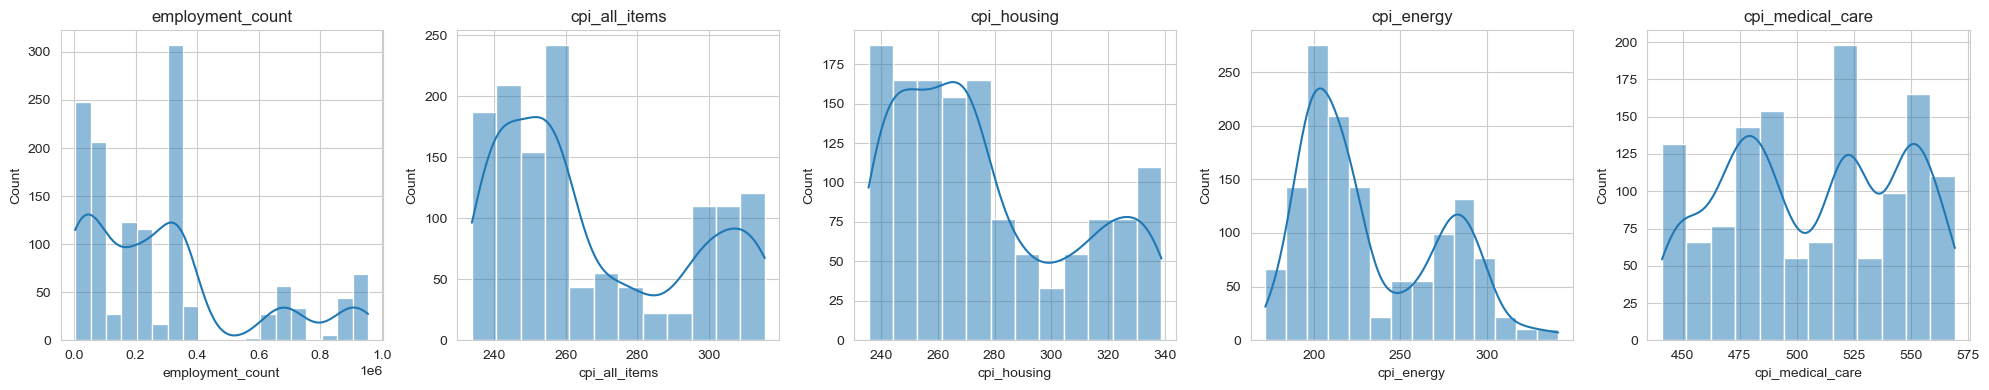

In [26]:
numeric_cols = [c for c in ['employment_count', 'cpi_all_items', 'cpi_housing', 'cpi_energy', 'cpi_medical_care']
                if c in master_df.columns]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(master_df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 8. Missingness by county

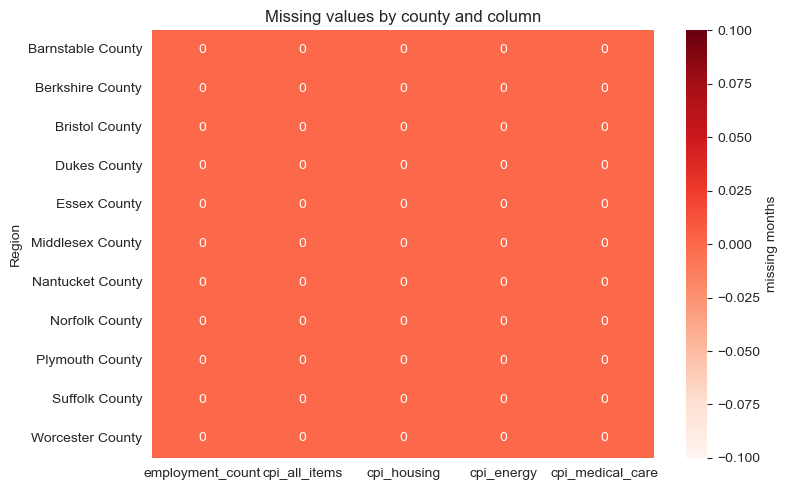

In [27]:
missing_by_region = master_df.groupby('Region')[numeric_cols].apply(lambda x: x.isnull().sum())

plt.figure(figsize=(8, 5))
sns.heatmap(missing_by_region, annot=True, fmt='d', cmap='Reds', cbar_kws={'label': 'missing months'})
plt.title('Missing values by county and column')
plt.tight_layout()
plt.show()

## 9. Trends over time

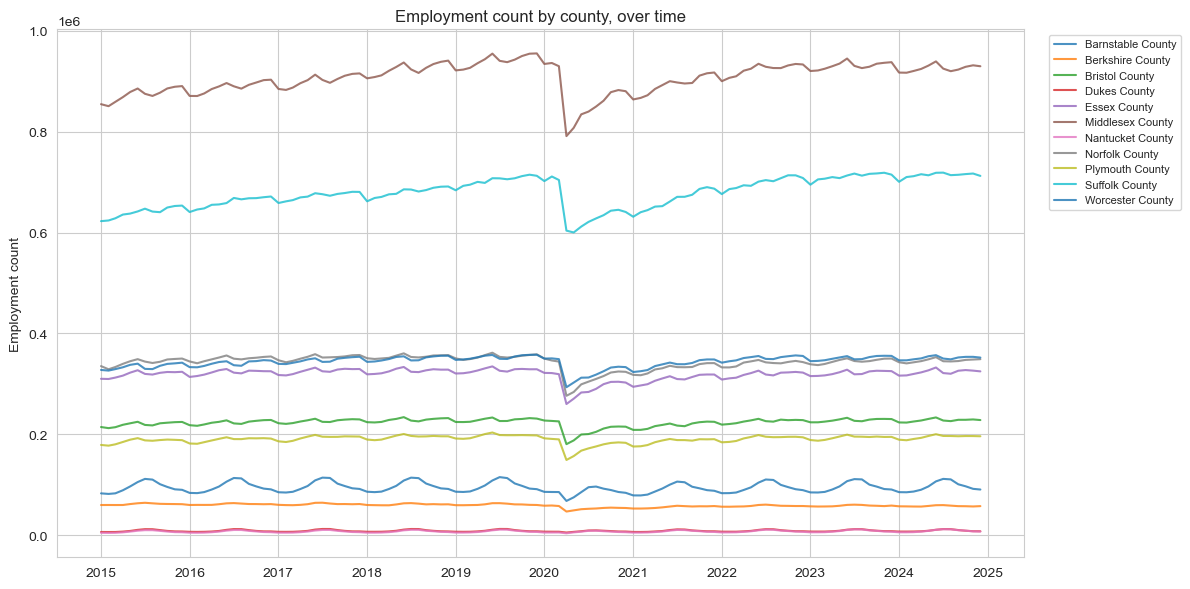

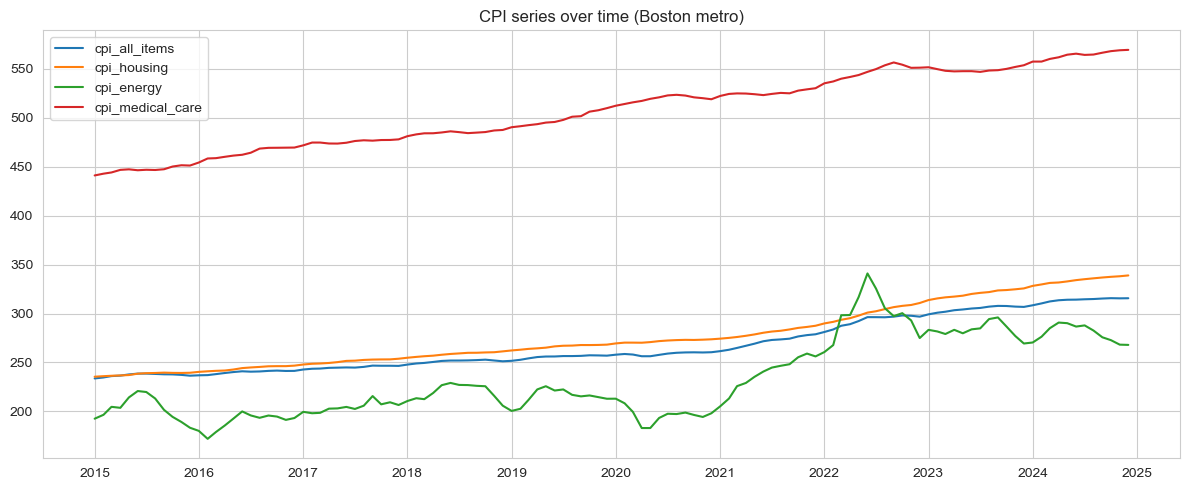

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
for region, group in master_df.groupby('Region'):
    ax.plot(group['Date'], group['employment_count'], label=region, alpha=0.8)
ax.set_title('Employment count by county, over time')
ax.set_ylabel('Employment count')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


cpi_cols = [c for c in ['cpi_all_items', 'cpi_housing', 'cpi_energy', 'cpi_medical_care'] if c in master_df.columns]
cpi_over_time = master_df.drop_duplicates(subset='Date')[['Date'] + cpi_cols]

fig, ax = plt.subplots(figsize=(12, 5))
for col in cpi_cols:
    ax.plot(cpi_over_time['Date'], cpi_over_time[col], label=col)
ax.set_title('CPI series over time (Boston metro)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Correlation

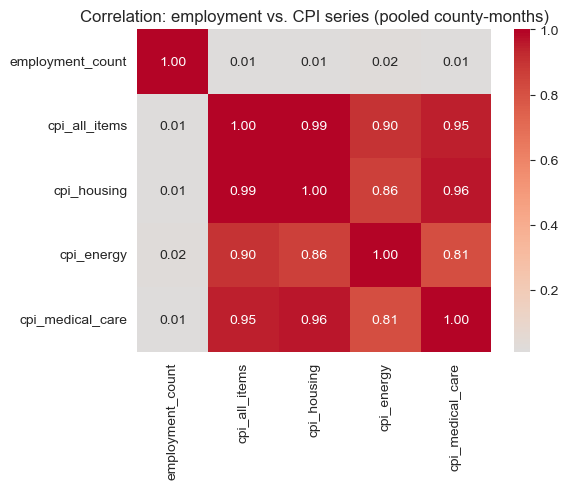

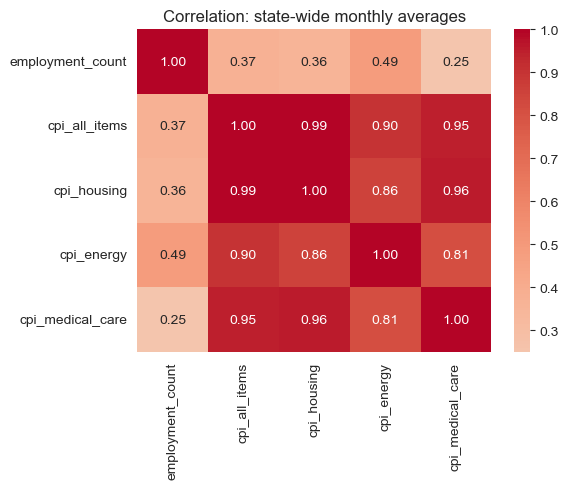

In [29]:
corr = master_df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: employment vs. CPI series (pooled county-months)')
plt.tight_layout()
plt.show()


monthly = master_df.groupby('Date')[numeric_cols].mean()
monthly_corr = monthly.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(monthly_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: state-wide monthly averages')
plt.tight_layout()
plt.show()

## 11. Appendix — diagnosing the unemployment merge bug (not used above)

In [30]:

sample_date = df_with_unemployment['Date'].iloc[0]
same_date = df_with_unemployment[df_with_unemployment['Date'] == sample_date]

values_by_region = same_date.groupby('Region')['unemployment rate'].apply(lambda s: tuple(sorted(s.dropna())))
print(values_by_region)
print()
print('Are all regions showing the identical set of values?', values_by_region.nunique() == 1)

Region
Total Covered Total, all industries for All establishment sizes in Barnstable County    (5.0, 5.2, 5.4, 6.0, 6.8, 7.6, 9.6)
Total Covered Total, all industries for All establishment sizes in Berkshire County     (5.0, 5.2, 5.4, 6.0, 6.8, 7.6, 9.6)
Total Covered Total, all industries for All establishment sizes in Bristol County       (5.0, 5.2, 5.4, 6.0, 6.8, 7.6, 9.6)
Total Covered Total, all industries for All establishment sizes in Dukes County         (5.0, 5.2, 5.4, 6.0, 6.8, 7.6, 9.6)
Total Covered Total, all industries for All establishment sizes in Essex County         (5.0, 5.2, 5.4, 6.0, 6.8, 7.6, 9.6)
Total Covered Total, all industries for All establishment sizes in Middlesex County     (5.0, 5.2, 5.4, 6.0, 6.8, 7.6, 9.6)
Total Covered Total, all industries for All establishment sizes in Nantucket County     (5.0, 5.2, 5.4, 6.0, 6.8, 7.6, 9.6)
Total Covered Total, all industries for All establishment sizes in Norfolk County       (5.0, 5.2, 5.4, 6.0, 6.8, 7.6, 9.6)
T